Matplotlib is building the font cache; this may take a moment.
/home/hansstem/anaconda3/envs/sclc/lib/python3.12/site-packages/nibabel/optpkg.py:104: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  pkg = __import__(name, fromlist=fromlist)


Total volumes found: 1
Volumes with annotations: 1
Volumes without annotations: 0

Patient folders: 1
Extracting metadata from all volumes...
Successfully extracted metadata from 1 volumes
VOLUME DIMENSIONS SUMMARY
       dim_x  dim_y  dim_z
count    1.0    1.0    1.0
mean   512.0  512.0  736.0
std      NaN    NaN    NaN
min    512.0  512.0  736.0
25%    512.0  512.0  736.0
50%    512.0  512.0  736.0
75%    512.0  512.0  736.0
max    512.0  512.0  736.0

VOXEL SPACING SUMMARY (mm)
       pixel_spacing_x  pixel_spacing_y  slice_thickness
count         1.000000         1.000000              1.0
mean          0.759766         0.759766              0.5
std                NaN              NaN              NaN
min           0.759766         0.759766              0.5
25%           0.759766         0.759766              0.5
50%           0.759766         0.759766              0.5
75%           0.759766         0.759766              0.5
max           0.759766         0.759766              0.5


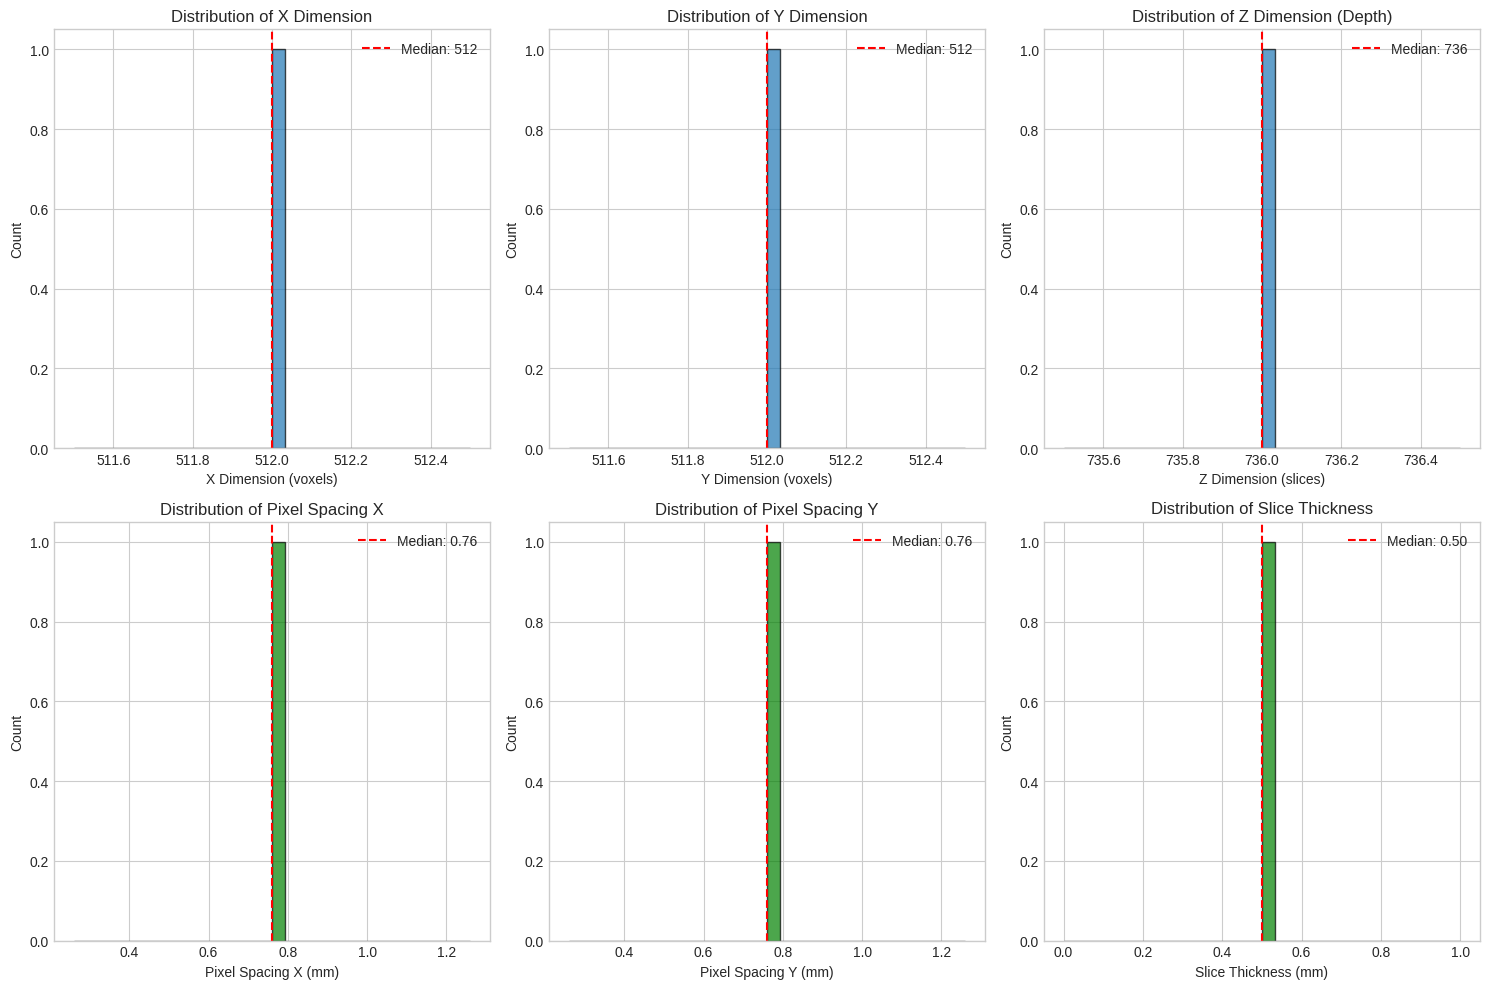

RESAMPLING ASSESSMENT

Standard deviation of voxel spacing:
pixel_spacing_x   NaN
pixel_spacing_y   NaN
slice_thickness   NaN
dtype: float32

Unique pixel spacing X values: 1
Unique pixel spacing Y values: 1
Unique slice thickness values: 1

✓  Voxel spacing is relatively consistent across the dataset.
Analyzing intensity values...
Successfully analyzed 1 volumes
INTENSITY (HOUNSFIELD UNITS) SUMMARY - FULL VOLUME
       volume_min  volume_max  volume_mean  volume_std
count         1.0         1.0     1.000000    1.000000
mean      -1024.0      3071.0  -600.446084  488.650701
std           NaN         NaN          NaN         NaN
min       -1024.0      3071.0  -600.446084  488.650701
25%       -1024.0      3071.0  -600.446084  488.650701
50%       -1024.0      3071.0  -600.446084  488.650701
75%       -1024.0      3071.0  -600.446084  488.650701
max       -1024.0      3071.0  -600.446084  488.650701

INTENSITY SUMMARY - TUMOR REGIONS
       tumor_mean   tumor_std  tumor_min  tumor_max
c

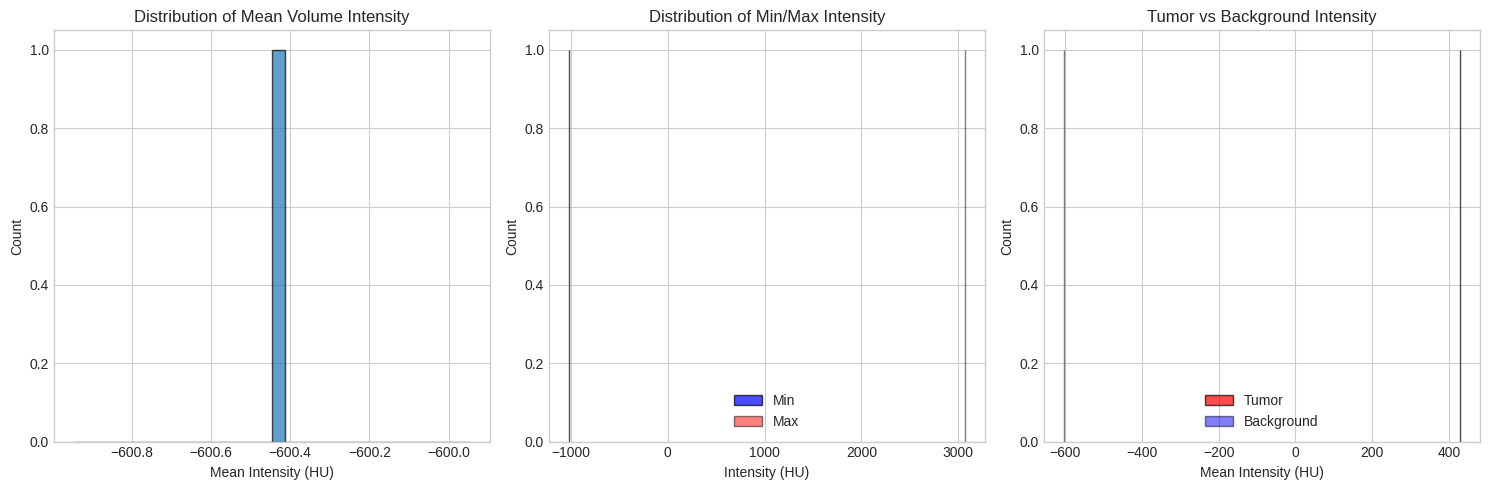

WINDOWING RECOMMENDATIONS FOR CT VISUALIZATION

Standard CT Windows:
  Lung: Level=-600, Width=1500
  Mediastinum: Level=40, Width=400
  Bone: Level=400, Width=1800
  Soft Tissue: Level=50, Width=350

Recommended tumor-specific window:
  Level: 429 HU
  Width: 561 HU (±2 std)
Analyzing tumor morphology...
Successfully analyzed morphology for 1 tumors
TUMOR MORPHOLOGY SUMMARY
       tumor_volume_cm3   bbox_x_mm   bbox_y_mm  bbox_z_mm
count          1.000000    1.000000    1.000000        1.0
mean         167.490465  220.332031  132.958984      187.0
std                 NaN         NaN         NaN        NaN
min          167.490465  220.332031  132.958984      187.0
25%          167.490465  220.332031  132.958984      187.0
50%          167.490465  220.332031  132.958984      187.0
75%          167.490465  220.332031  132.958984      187.0
max          167.490465  220.332031  132.958984      187.0

ASPECT RATIO SUMMARY
       aspect_ratio_xy  aspect_ratio_xz  aspect_ratio_yz  sphericity_

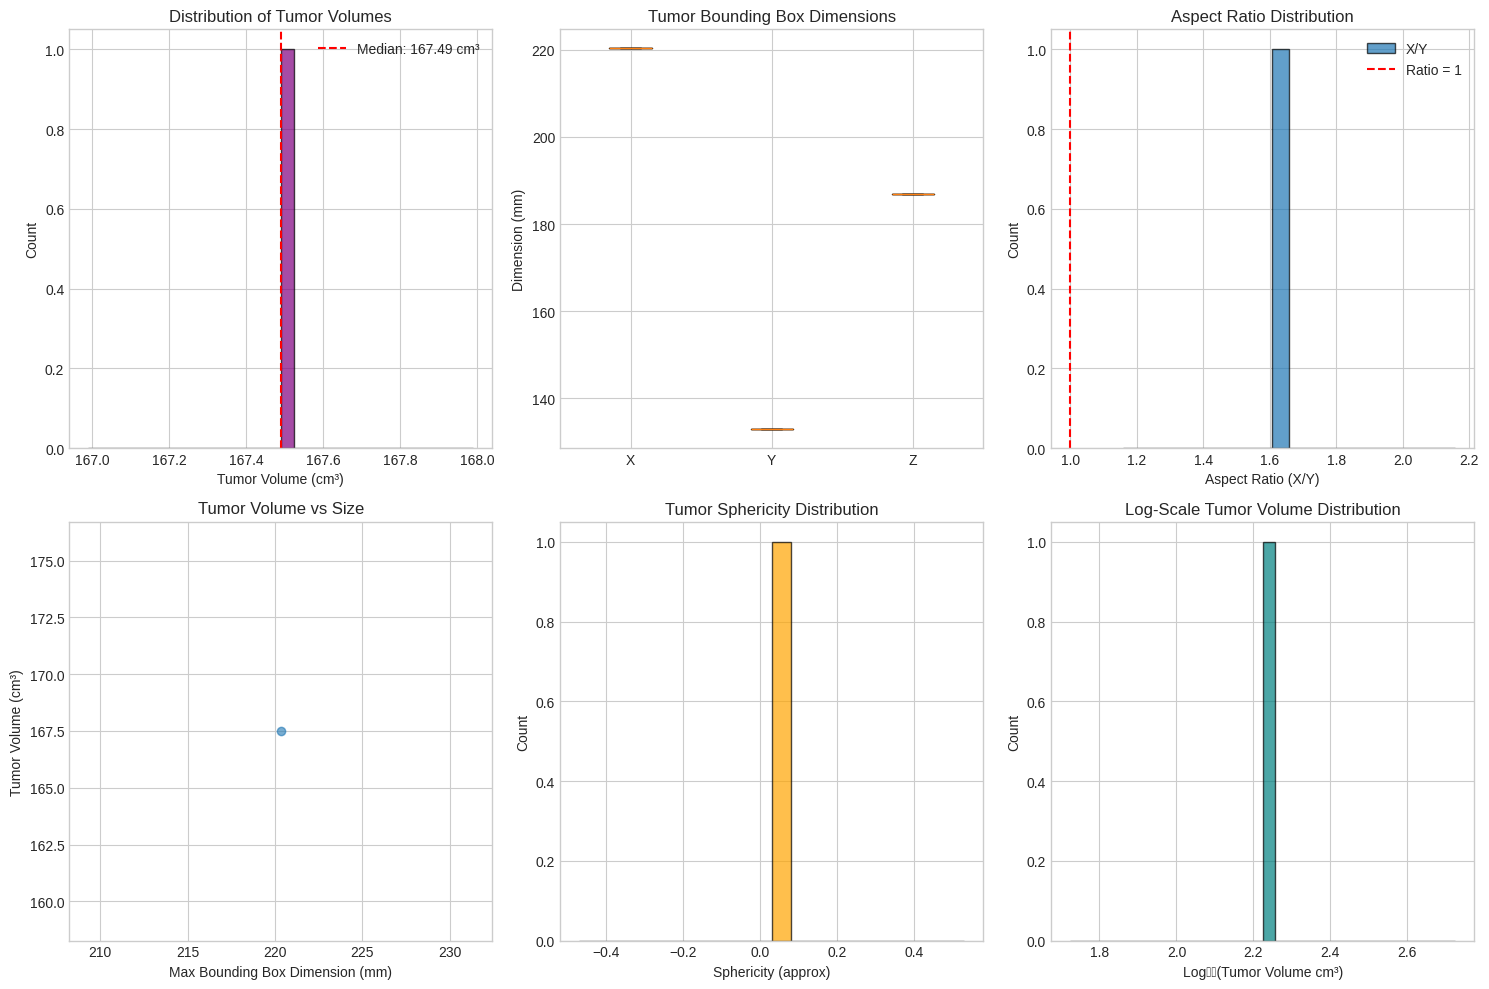

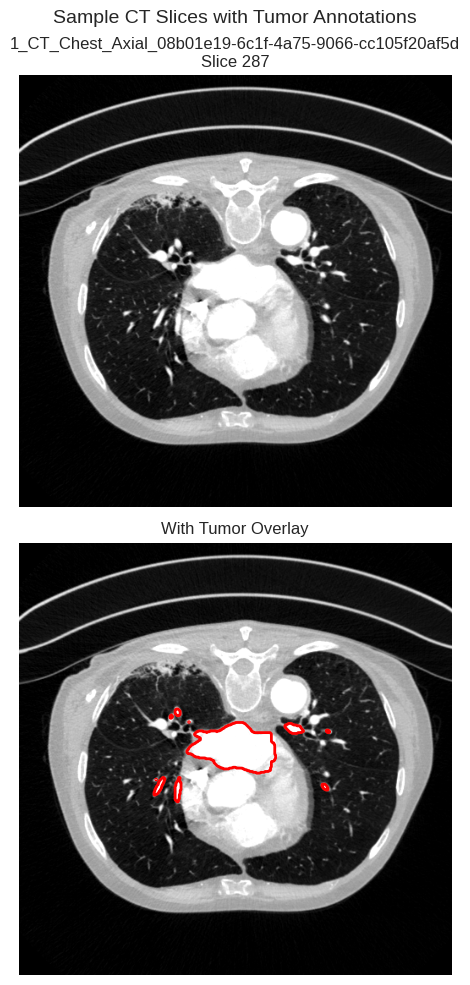

SUMMARY STATISTICS
                   Metric            Value     Unit
            Total Volumes                1    scans
 Volumes with Annotations                1    scans
          Unique Patients                1 patients
       Median X Dimension              512   voxels
       Median Y Dimension              512   voxels
       Median Z Dimension              736   slices
 Median Pixel Spacing (X)            0.760       mm
   Median Slice Thickness            0.500       mm
    Mean Volume Intensity           -600.4       HU
   Volume Intensity Range    [-1024, 3071]       HU
      Median Tumor Volume           167.49      cm³
       Tumor Volume Range [167.49, 167.49]      cm³
Median Aspect Ratio (X/Y)             1.66    ratio

✓ Summary saved to 'eda_summary.csv'
RECOMMENDATIONS FOR MODEL TRAINING
✓  Image dimensions are relatively consistent.
✓  Voxel spacing is consistent across scans.
ℹ️  Median tumor size is ~177mm. Consider larger crop sizes (128-256mm).
✓  All volumes 

In [1]:
# %% [markdown]
# # Chest CT Data Exploration for Lung Cancer Classification
# 
# This notebook performs exploratory data analysis on chest CT scans to assess data suitability for training ResNet, DenseNet, and Vision Transformer models.

# %% [markdown]
# ## 1. Setup and Imports

# %%
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

# %% [markdown]
# ## 2. Configuration and Data Discovery

# %%
# Configuration
ROOT_DIR = "/home/hansstem/Data/CT_test"

def discover_data(root_dir):
    """Traverse the directory structure and find all volumes and annotations."""
    data_records = []
    
    for patient_folder in sorted(os.listdir(root_dir)):
        patient_path = os.path.join(root_dir, patient_folder)
        if not os.path.isdir(patient_path):
            continue
            
        volumes_path = os.path.join(patient_path, "volumes")
        annotations_path = os.path.join(patient_path, "annotations")
        
        # Find all volume files
        if os.path.exists(volumes_path):
            volume_files = glob.glob(os.path.join(volumes_path, "*.nii.gz")) + \
                          glob.glob(os.path.join(volumes_path, "*.nii"))
            
            for vol_file in volume_files:
                vol_name = os.path.basename(vol_file).replace(".nii.gz", "").replace(".nii", "")
                
                # Find matching annotation
                annotation_file = None
                if os.path.exists(annotations_path):
                    # Look for annotation files that start with the volume name
                    ann_patterns = [
                        os.path.join(annotations_path, f"{vol_name}_label*.nii.gz"),
                        os.path.join(annotations_path, f"{vol_name}_label*.nii"),
                        os.path.join(annotations_path, f"{vol_name}*.nii.gz"),
                        os.path.join(annotations_path, f"{vol_name}*.nii"),
                    ]
                    for pattern in ann_patterns:
                        matches = glob.glob(pattern)
                        if matches:
                            annotation_file = matches[0]
                            break
                
                data_records.append({
                    "patient_id": patient_folder,
                    "volume_name": vol_name,
                    "volume_path": vol_file,
                    "annotation_path": annotation_file,
                    "has_annotation": annotation_file is not None
                })
    
    return pd.DataFrame(data_records)

# Discover all data
df_data = discover_data(ROOT_DIR)
print(f"Total volumes found: {len(df_data)}")
print(f"Volumes with annotations: {df_data['has_annotation'].sum()}")
print(f"Volumes without annotations: {(~df_data['has_annotation']).sum()}")
print(f"\nPatient folders: {df_data['patient_id'].nunique()}")
df_data.head(10)

# %% [markdown]
# ## 3. Image Metadata & Acquisition Analysis

# %%
def extract_nifti_metadata(volume_path):
    """Extract metadata from a NIfTI file."""
    try:
        img = nib.load(volume_path)
        header = img.header
        
        # Get dimensions
        shape = img.shape
        
        # Get voxel spacing (pixel spacing + slice thickness)
        zooms = header.get_zooms()
        
        # Get data type
        dtype = header.get_data_dtype()
        
        return {
            "dim_x": shape[0] if len(shape) > 0 else None,
            "dim_y": shape[1] if len(shape) > 1 else None,
            "dim_z": shape[2] if len(shape) > 2 else None,
            "pixel_spacing_x": zooms[0] if len(zooms) > 0 else None,
            "pixel_spacing_y": zooms[1] if len(zooms) > 1 else None,
            "slice_thickness": zooms[2] if len(zooms) > 2 else None,
            "dtype": str(dtype),
            "n_dimensions": len(shape),
        }
    except Exception as e:
        print(f"Error loading {volume_path}: {e}")
        return None

# Extract metadata for all volumes
print("Extracting metadata from all volumes...")
metadata_list = []
for idx, row in df_data.iterrows():
    meta = extract_nifti_metadata(row['volume_path'])
    if meta:
        meta['volume_name'] = row['volume_name']
        meta['patient_id'] = row['patient_id']
        metadata_list.append(meta)

df_metadata = pd.DataFrame(metadata_list)
print(f"Successfully extracted metadata from {len(df_metadata)} volumes")
df_metadata.head()

# %%
# Summary statistics for metadata
print("=" * 60)
print("VOLUME DIMENSIONS SUMMARY")
print("=" * 60)
print(df_metadata[['dim_x', 'dim_y', 'dim_z']].describe())

print("\n" + "=" * 60)
print("VOXEL SPACING SUMMARY (mm)")
print("=" * 60)
print(df_metadata[['pixel_spacing_x', 'pixel_spacing_y', 'slice_thickness']].describe())

# %%
# Visualize metadata distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Volume dimensions
axes[0, 0].hist(df_metadata['dim_x'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('X Dimension (voxels)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of X Dimension')
axes[0, 0].axvline(df_metadata['dim_x'].median(), color='red', linestyle='--', label=f'Median: {df_metadata["dim_x"].median():.0f}')
axes[0, 0].legend()

axes[0, 1].hist(df_metadata['dim_y'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Y Dimension (voxels)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of Y Dimension')
axes[0, 1].axvline(df_metadata['dim_y'].median(), color='red', linestyle='--', label=f'Median: {df_metadata["dim_y"].median():.0f}')
axes[0, 1].legend()

axes[0, 2].hist(df_metadata['dim_z'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0, 2].set_xlabel('Z Dimension (slices)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Distribution of Z Dimension (Depth)')
axes[0, 2].axvline(df_metadata['dim_z'].median(), color='red', linestyle='--', label=f'Median: {df_metadata["dim_z"].median():.0f}')
axes[0, 2].legend()

# Voxel spacing
axes[1, 0].hist(df_metadata['pixel_spacing_x'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Pixel Spacing X (mm)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Distribution of Pixel Spacing X')
axes[1, 0].axvline(df_metadata['pixel_spacing_x'].median(), color='red', linestyle='--', label=f'Median: {df_metadata["pixel_spacing_x"].median():.2f}')
axes[1, 0].legend()

axes[1, 1].hist(df_metadata['pixel_spacing_y'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Pixel Spacing Y (mm)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Distribution of Pixel Spacing Y')
axes[1, 1].axvline(df_metadata['pixel_spacing_y'].median(), color='red', linestyle='--', label=f'Median: {df_metadata["pixel_spacing_y"].median():.2f}')
axes[1, 1].legend()

axes[1, 2].hist(df_metadata['slice_thickness'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 2].set_xlabel('Slice Thickness (mm)')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Distribution of Slice Thickness')
axes[1, 2].axvline(df_metadata['slice_thickness'].median(), color='red', linestyle='--', label=f'Median: {df_metadata["slice_thickness"].median():.2f}')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('metadata_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# Check if resampling is needed
print("=" * 60)
print("RESAMPLING ASSESSMENT")
print("=" * 60)

spacing_variance = df_metadata[['pixel_spacing_x', 'pixel_spacing_y', 'slice_thickness']].std()
print(f"\nStandard deviation of voxel spacing:")
print(spacing_variance)

unique_spacings_x = df_metadata['pixel_spacing_x'].nunique()
unique_spacings_y = df_metadata['pixel_spacing_y'].nunique()
unique_slice_thickness = df_metadata['slice_thickness'].nunique()

print(f"\nUnique pixel spacing X values: {unique_spacings_x}")
print(f"Unique pixel spacing Y values: {unique_spacings_y}")
print(f"Unique slice thickness values: {unique_slice_thickness}")

if spacing_variance.max() > 0.5:
    print("\n⚠️  RECOMMENDATION: Significant variation in voxel spacing detected.")
    print("   Consider resampling to isotropic voxels (e.g., 1mm x 1mm x 1mm)")
else:
    print("\n✓  Voxel spacing is relatively consistent across the dataset.")

# %% [markdown]
# ## 4. Intensity Analysis (Hounsfield Units)

# %%
def analyze_intensity(volume_path, annotation_path=None, sample_slices=10):
    """Analyze intensity values (Hounsfield Units) for a volume."""
    try:
        img = nib.load(volume_path)
        data = img.get_fdata()
        
        # Sample slices for efficiency
        if data.shape[2] > sample_slices:
            slice_indices = np.linspace(0, data.shape[2]-1, sample_slices, dtype=int)
            data_sample = data[:, :, slice_indices]
        else:
            data_sample = data
        
        result = {
            "volume_min": float(np.min(data)),
            "volume_max": float(np.max(data)),
            "volume_mean": float(np.mean(data)),
            "volume_std": float(np.std(data)),
            "volume_median": float(np.median(data)),
        }
        
        # Analyze tumor region if annotation exists
        if annotation_path and os.path.exists(annotation_path):
            mask_img = nib.load(annotation_path)
            mask = mask_img.get_fdata()
            
            if mask.shape == data.shape:
                tumor_mask = mask > 0
                background_mask = mask == 0
                
                if tumor_mask.sum() > 0:
                    result["tumor_mean"] = float(np.mean(data[tumor_mask]))
                    result["tumor_std"] = float(np.std(data[tumor_mask]))
                    result["tumor_min"] = float(np.min(data[tumor_mask]))
                    result["tumor_max"] = float(np.max(data[tumor_mask]))
                    result["tumor_voxel_count"] = int(tumor_mask.sum())
                
                if background_mask.sum() > 0:
                    result["background_mean"] = float(np.mean(data[background_mask]))
                    result["background_std"] = float(np.std(data[background_mask]))
        
        return result
    except Exception as e:
        print(f"Error analyzing {volume_path}: {e}")
        return None

# Analyze intensity for all volumes
print("Analyzing intensity values...")
intensity_list = []
for idx, row in df_data.iterrows():
    intensity_stats = analyze_intensity(row['volume_path'], row['annotation_path'])
    if intensity_stats:
        intensity_stats['volume_name'] = row['volume_name']
        intensity_stats['patient_id'] = row['patient_id']
        intensity_stats['has_annotation'] = row['has_annotation']
        intensity_list.append(intensity_stats)

df_intensity = pd.DataFrame(intensity_list)
print(f"Successfully analyzed {len(df_intensity)} volumes")

# %%
# Intensity statistics summary
print("=" * 60)
print("INTENSITY (HOUNSFIELD UNITS) SUMMARY - FULL VOLUME")
print("=" * 60)
print(df_intensity[['volume_min', 'volume_max', 'volume_mean', 'volume_std']].describe())

if 'tumor_mean' in df_intensity.columns:
    print("\n" + "=" * 60)
    print("INTENSITY SUMMARY - TUMOR REGIONS")
    print("=" * 60)
    tumor_cols = ['tumor_mean', 'tumor_std', 'tumor_min', 'tumor_max']
    print(df_intensity[tumor_cols].dropna().describe())
    
    print("\n" + "=" * 60)
    print("INTENSITY SUMMARY - BACKGROUND")
    print("=" * 60)
    print(df_intensity[['background_mean', 'background_std']].dropna().describe())

# %%
# Visualize intensity distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Volume intensity range
axes[0].hist(df_intensity['volume_mean'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Mean Intensity (HU)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Mean Volume Intensity')

axes[1].hist(df_intensity['volume_min'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='blue', label='Min')
axes[1].hist(df_intensity['volume_max'].dropna(), bins=30, edgecolor='black', alpha=0.5, color='red', label='Max')
axes[1].set_xlabel('Intensity (HU)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Min/Max Intensity')
axes[1].legend()

# Tumor vs Background (if available)
if 'tumor_mean' in df_intensity.columns and df_intensity['tumor_mean'].notna().sum() > 0:
    axes[2].hist(df_intensity['tumor_mean'].dropna(), bins=20, edgecolor='black', alpha=0.7, color='red', label='Tumor')
    axes[2].hist(df_intensity['background_mean'].dropna(), bins=20, edgecolor='black', alpha=0.5, color='blue', label='Background')
    axes[2].set_xlabel('Mean Intensity (HU)')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Tumor vs Background Intensity')
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'No tumor annotations\navailable', ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
    axes[2].set_title('Tumor vs Background (N/A)')

plt.tight_layout()
plt.savefig('intensity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# %%
# Windowing recommendations based on data
print("=" * 60)
print("WINDOWING RECOMMENDATIONS FOR CT VISUALIZATION")
print("=" * 60)

# Common CT windows
windows = {
    "Lung": {"level": -600, "width": 1500},
    "Mediastinum": {"level": 40, "width": 400},
    "Bone": {"level": 400, "width": 1800},
    "Soft Tissue": {"level": 50, "width": 350},
}

print("\nStandard CT Windows:")
for name, params in windows.items():
    print(f"  {name}: Level={params['level']}, Width={params['width']}")

if 'tumor_mean' in df_intensity.columns and df_intensity['tumor_mean'].notna().sum() > 0:
    tumor_mean = df_intensity['tumor_mean'].mean()
    tumor_std = df_intensity['tumor_std'].mean()
    print(f"\nRecommended tumor-specific window:")
    print(f"  Level: {tumor_mean:.0f} HU")
    print(f"  Width: {4 * tumor_std:.0f} HU (±2 std)")

# %% [markdown]
# ## 5. Tumor Morphology Analysis

# %%
def analyze_tumor_morphology(volume_path, annotation_path):
    """Analyze tumor morphology including volume and aspect ratios."""
    try:
        img = nib.load(volume_path)
        mask_img = nib.load(annotation_path)
        
        data = img.get_fdata()
        mask = mask_img.get_fdata()
        zooms = img.header.get_zooms()
        
        tumor_mask = mask > 0
        
        if tumor_mask.sum() == 0:
            return None
        
        # Calculate volume
        voxel_volume = zooms[0] * zooms[1] * zooms[2]  # mm³
        tumor_voxel_count = tumor_mask.sum()
        tumor_volume_mm3 = tumor_voxel_count * voxel_volume
        tumor_volume_cm3 = tumor_volume_mm3 / 1000  # Convert to cm³
        
        # Find bounding box
        coords = np.where(tumor_mask)
        bbox_min = [coords[i].min() for i in range(3)]
        bbox_max = [coords[i].max() for i in range(3)]
        
        # Bounding box dimensions in voxels and mm
        bbox_dims_voxels = [bbox_max[i] - bbox_min[i] + 1 for i in range(3)]
        bbox_dims_mm = [bbox_dims_voxels[i] * zooms[i] for i in range(3)]
        
        # Aspect ratios
        aspect_ratio_xy = bbox_dims_mm[0] / bbox_dims_mm[1] if bbox_dims_mm[1] > 0 else 0
        aspect_ratio_xz = bbox_dims_mm[0] / bbox_dims_mm[2] if bbox_dims_mm[2] > 0 else 0
        aspect_ratio_yz = bbox_dims_mm[1] / bbox_dims_mm[2] if bbox_dims_mm[2] > 0 else 0
        
        # Sphericity (how sphere-like the tumor is)
        # Approximate using bounding box
        max_dim = max(bbox_dims_mm)
        if max_dim > 0:
            sphere_volume = (4/3) * np.pi * (max_dim/2)**3
            sphericity = tumor_volume_mm3 / sphere_volume if sphere_volume > 0 else 0
        else:
            sphericity = 0
        
        # Find center of mass slice
        center_of_mass = ndimage.center_of_mass(tumor_mask)
        center_slice = int(center_of_mass[2])
        
        return {
            "tumor_voxel_count": int(tumor_voxel_count),
            "tumor_volume_mm3": float(tumor_volume_mm3),
            "tumor_volume_cm3": float(tumor_volume_cm3),
            "bbox_x_mm": float(bbox_dims_mm[0]),
            "bbox_y_mm": float(bbox_dims_mm[1]),
            "bbox_z_mm": float(bbox_dims_mm[2]),
            "aspect_ratio_xy": float(aspect_ratio_xy),
            "aspect_ratio_xz": float(aspect_ratio_xz),
            "aspect_ratio_yz": float(aspect_ratio_yz),
            "sphericity_approx": float(sphericity),
            "center_slice": center_slice,
            "bbox_min": bbox_min,
            "bbox_max": bbox_max,
        }
    except Exception as e:
        print(f"Error analyzing morphology: {e}")
        return None

# Analyze morphology for volumes with annotations
print("Analyzing tumor morphology...")
morphology_list = []
df_with_annotations = df_data[df_data['has_annotation']]

for idx, row in df_with_annotations.iterrows():
    morph = analyze_tumor_morphology(row['volume_path'], row['annotation_path'])
    if morph:
        morph['volume_name'] = row['volume_name']
        morph['patient_id'] = row['patient_id']
        morphology_list.append(morph)

if morphology_list:
    df_morphology = pd.DataFrame(morphology_list)
    print(f"Successfully analyzed morphology for {len(df_morphology)} tumors")
else:
    df_morphology = pd.DataFrame()
    print("No tumor morphology data available (no valid annotations found)")

# %%
if len(df_morphology) > 0:
    print("=" * 60)
    print("TUMOR MORPHOLOGY SUMMARY")
    print("=" * 60)
    print(df_morphology[['tumor_volume_cm3', 'bbox_x_mm', 'bbox_y_mm', 'bbox_z_mm']].describe())
    
    print("\n" + "=" * 60)
    print("ASPECT RATIO SUMMARY")
    print("=" * 60)
    print(df_morphology[['aspect_ratio_xy', 'aspect_ratio_xz', 'aspect_ratio_yz', 'sphericity_approx']].describe())

# %%
if len(df_morphology) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Tumor volume distribution
    axes[0, 0].hist(df_morphology['tumor_volume_cm3'], bins=30, edgecolor='black', alpha=0.7, color='purple')
    axes[0, 0].set_xlabel('Tumor Volume (cm³)')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Distribution of Tumor Volumes')
    axes[0, 0].axvline(df_morphology['tumor_volume_cm3'].median(), color='red', linestyle='--', 
                       label=f'Median: {df_morphology["tumor_volume_cm3"].median():.2f} cm³')
    axes[0, 0].legend()
    
    # Bounding box dimensions
    axes[0, 1].boxplot([df_morphology['bbox_x_mm'], df_morphology['bbox_y_mm'], df_morphology['bbox_z_mm']], 
                       labels=['X', 'Y', 'Z'])
    axes[0, 1].set_ylabel('Dimension (mm)')
    axes[0, 1].set_title('Tumor Bounding Box Dimensions')
    
    # Aspect ratios
    axes[0, 2].hist(df_morphology['aspect_ratio_xy'], bins=20, edgecolor='black', alpha=0.7, label='X/Y')
    axes[0, 2].axvline(1.0, color='red', linestyle='--', label='Ratio = 1')
    axes[0, 2].set_xlabel('Aspect Ratio (X/Y)')
    axes[0, 2].set_ylabel('Count')
    axes[0, 2].set_title('Aspect Ratio Distribution')
    axes[0, 2].legend()
    
    # Scatter: Volume vs Max Dimension
    max_dim = df_morphology[['bbox_x_mm', 'bbox_y_mm', 'bbox_z_mm']].max(axis=1)
    axes[1, 0].scatter(max_dim, df_morphology['tumor_volume_cm3'], alpha=0.6)
    axes[1, 0].set_xlabel('Max Bounding Box Dimension (mm)')
    axes[1, 0].set_ylabel('Tumor Volume (cm³)')
    axes[1, 0].set_title('Tumor Volume vs Size')
    
    # Sphericity
    axes[1, 1].hist(df_morphology['sphericity_approx'], bins=20, edgecolor='black', alpha=0.7, color='orange')
    axes[1, 1].set_xlabel('Sphericity (approx)')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title('Tumor Sphericity Distribution')
    
    # Log volume for better visualization of small tumors
    axes[1, 2].hist(np.log10(df_morphology['tumor_volume_cm3'] + 0.001), bins=30, edgecolor='black', alpha=0.7, color='teal')
    axes[1, 2].set_xlabel('Log₁₀(Tumor Volume cm³)')
    axes[1, 2].set_ylabel('Count')
    axes[1, 2].set_title('Log-Scale Tumor Volume Distribution')
    
    plt.tight_layout()
    plt.savefig('morphology_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No morphology data to visualize (no annotations available)")

# %% [markdown]
# ## 6. Visual Samples

# %%
def visualize_samples(df_data, n_samples=3):
    """Visualize random sample slices with tumor overlay."""
    df_with_ann = df_data[df_data['has_annotation']]
    
    if len(df_with_ann) == 0:
        print("No samples with annotations available for visualization")
        # Show samples without annotations instead
        df_sample = df_data.sample(min(n_samples, len(df_data)))
        
        fig, axes = plt.subplots(1, len(df_sample), figsize=(5*len(df_sample), 5))
        if len(df_sample) == 1:
            axes = [axes]
            
        for idx, (_, row) in enumerate(df_sample.iterrows()):
            img = nib.load(row['volume_path'])
            data = img.get_fdata()
            
            # Middle slice
            mid_slice = data.shape[2] // 2
            slice_data = data[:, :, mid_slice]
            
            # Apply lung window
            slice_windowed = np.clip(slice_data, -1000, 400)
            
            axes[idx].imshow(slice_windowed.T, cmap='gray', origin='lower')
            axes[idx].set_title(f"{row['volume_name']}\nSlice {mid_slice}/{data.shape[2]}")
            axes[idx].axis('off')
        
        plt.suptitle('Sample CT Slices (No Annotations)', fontsize=14)
        plt.tight_layout()
        plt.savefig('sample_slices_no_annotations.png', dpi=150, bbox_inches='tight')
        plt.show()
        return
    
    # Sample from annotated volumes
    n_to_sample = min(n_samples, len(df_with_ann))
    df_sample = df_with_ann.sample(n_to_sample)
    
    fig, axes = plt.subplots(2, n_to_sample, figsize=(5*n_to_sample, 10))
    if n_to_sample == 1:
        axes = axes.reshape(-1, 1)
    
    for idx, (_, row) in enumerate(df_sample.iterrows()):
        img = nib.load(row['volume_path'])
        mask_img = nib.load(row['annotation_path'])
        
        data = img.get_fdata()
        mask = mask_img.get_fdata()
        
        # Find center of tumor
        tumor_coords = np.where(mask > 0)
        if len(tumor_coords[2]) > 0:
            center_slice = int(np.median(tumor_coords[2]))
        else:
            center_slice = data.shape[2] // 2
        
        slice_data = data[:, :, center_slice]
        slice_mask = mask[:, :, center_slice]
        
        # Apply lung window for better visualization
        slice_windowed = np.clip(slice_data, -1000, 400)
        
        # Top row: CT only
        axes[0, idx].imshow(slice_windowed.T, cmap='gray', origin='lower')
        axes[0, idx].set_title(f"{row['volume_name']}\nSlice {center_slice}")
        axes[0, idx].axis('off')
        
        # Bottom row: CT with mask overlay
        axes[1, idx].imshow(slice_windowed.T, cmap='gray', origin='lower')
        
        # Overlay mask contour
        if slice_mask.max() > 0:
            axes[1, idx].contour(slice_mask.T, colors='red', linewidths=2, levels=[0.5])
        
        axes[1, idx].set_title(f"With Tumor Overlay")
        axes[1, idx].axis('off')
    
    plt.suptitle('Sample CT Slices with Tumor Annotations', fontsize=14)
    plt.tight_layout()
    plt.savefig('sample_slices_with_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize samples
visualize_samples(df_data, n_samples=3)

# %% [markdown]
# ## 7. Summary Statistics Table

# %%
# Compile summary statistics
summary_data = {
    "Metric": [],
    "Value": [],
    "Unit": []
}

# Dataset overview
summary_data["Metric"].append("Total Volumes")
summary_data["Value"].append(len(df_data))
summary_data["Unit"].append("scans")

summary_data["Metric"].append("Volumes with Annotations")
summary_data["Value"].append(df_data['has_annotation'].sum())
summary_data["Unit"].append("scans")

summary_data["Metric"].append("Unique Patients")
summary_data["Value"].append(df_data['patient_id'].nunique())
summary_data["Unit"].append("patients")

# Dimensions
if len(df_metadata) > 0:
    summary_data["Metric"].append("Median X Dimension")
    summary_data["Value"].append(f"{df_metadata['dim_x'].median():.0f}")
    summary_data["Unit"].append("voxels")
    
    summary_data["Metric"].append("Median Y Dimension")
    summary_data["Value"].append(f"{df_metadata['dim_y'].median():.0f}")
    summary_data["Unit"].append("voxels")
    
    summary_data["Metric"].append("Median Z Dimension")
    summary_data["Value"].append(f"{df_metadata['dim_z'].median():.0f}")
    summary_data["Unit"].append("slices")
    
    summary_data["Metric"].append("Median Pixel Spacing (X)")
    summary_data["Value"].append(f"{df_metadata['pixel_spacing_x'].median():.3f}")
    summary_data["Unit"].append("mm")
    
    summary_data["Metric"].append("Median Slice Thickness")
    summary_data["Value"].append(f"{df_metadata['slice_thickness'].median():.3f}")
    summary_data["Unit"].append("mm")

# Intensity
if len(df_intensity) > 0:
    summary_data["Metric"].append("Mean Volume Intensity")
    summary_data["Value"].append(f"{df_intensity['volume_mean'].mean():.1f}")
    summary_data["Unit"].append("HU")
    
    summary_data["Metric"].append("Volume Intensity Range")
    summary_data["Value"].append(f"[{df_intensity['volume_min'].min():.0f}, {df_intensity['volume_max'].max():.0f}]")
    summary_data["Unit"].append("HU")

# Tumor morphology
if len(df_morphology) > 0:
    summary_data["Metric"].append("Median Tumor Volume")
    summary_data["Value"].append(f"{df_morphology['tumor_volume_cm3'].median():.2f}")
    summary_data["Unit"].append("cm³")
    
    summary_data["Metric"].append("Tumor Volume Range")
    summary_data["Value"].append(f"[{df_morphology['tumor_volume_cm3'].min():.2f}, {df_morphology['tumor_volume_cm3'].max():.2f}]")
    summary_data["Unit"].append("cm³")
    
    summary_data["Metric"].append("Median Aspect Ratio (X/Y)")
    summary_data["Value"].append(f"{df_morphology['aspect_ratio_xy'].median():.2f}")
    summary_data["Unit"].append("ratio")

df_summary = pd.DataFrame(summary_data)

print("=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(df_summary.to_string(index=False))

# Save summary to CSV
df_summary.to_csv('eda_summary.csv', index=False)
print("\n✓ Summary saved to 'eda_summary.csv'")

# %% [markdown]
# ## 8. Recommendations for Model Training

# %%
print("=" * 60)
print("RECOMMENDATIONS FOR MODEL TRAINING")
print("=" * 60)

recommendations = []

# Check dimension consistency
if len(df_metadata) > 0:
    dim_std = df_metadata[['dim_x', 'dim_y']].std().mean()
    if dim_std > 50:
        recommendations.append("⚠️  High variance in image dimensions. Consider center-cropping or padding to a fixed size (e.g., 224x224 for ViT/ResNet).")
    else:
        recommendations.append("✓  Image dimensions are relatively consistent.")

# Check spacing
if len(df_metadata) > 0:
    spacing_std = df_metadata[['pixel_spacing_x', 'pixel_spacing_y', 'slice_thickness']].std().max()
    if spacing_std > 0.5:
        recommendations.append("⚠️  Variable voxel spacing detected. Resample to isotropic voxels (e.g., 1mm³) before training.")
    else:
        recommendations.append("✓  Voxel spacing is consistent across scans.")

# Check tumor sizes
if len(df_morphology) > 0:
    vol_range = df_morphology['tumor_volume_cm3'].max() / (df_morphology['tumor_volume_cm3'].min() + 0.001)
    if vol_range > 100:
        recommendations.append("⚠️  Large variation in tumor sizes. Consider multi-scale approaches or size-stratified sampling.")
    
    median_bbox = df_morphology[['bbox_x_mm', 'bbox_y_mm']].median().mean()
    if median_bbox < 50:
        recommendations.append(f"ℹ️  Median tumor size is ~{median_bbox:.0f}mm. A crop size of 64-128mm may be sufficient.")
    else:
        recommendations.append(f"ℹ️  Median tumor size is ~{median_bbox:.0f}mm. Consider larger crop sizes (128-256mm).")

# Annotation coverage
ann_ratio = df_data['has_annotation'].mean()
if ann_ratio < 0.5:
    recommendations.append(f"⚠️  Only {ann_ratio*100:.1f}% of volumes have annotations. Consider data augmentation or semi-supervised learning.")
elif ann_ratio < 1.0:
    recommendations.append(f"ℹ️  {ann_ratio*100:.1f}% of volumes have annotations.")
else:
    recommendations.append("✓  All volumes have annotations.")

# General recommendations
recommendations.append("\n📋 GENERAL RECOMMENDATIONS:")
recommendations.append("   • Apply HU windowing (e.g., Lung: L=-600, W=1500) before normalization")
recommendations.append("   • Normalize to [0,1] or [-1,1] range after windowing")
recommendations.append("   • For Vision Transformer: resize/crop to 224x224 or 384x384")
recommendations.append("   • For ResNet/DenseNet: 224x224 is standard, can use 256x256")
recommendations.append("   • Consider 2.5D approach (adjacent slices as RGB channels) if using 2D models")

for rec in recommendations:
    print(rec)

# %% [markdown]
# ## 9. Save All Results

# %%
# Save all dataframes
df_data.to_csv('data_inventory.csv', index=False)
print("✓ Saved: data_inventory.csv")

if len(df_metadata) > 0:
    df_metadata.to_csv('metadata_analysis.csv', index=False)
    print("✓ Saved: metadata_analysis.csv")

if len(df_intensity) > 0:
    df_intensity.to_csv('intensity_analysis.csv', index=False)
    print("✓ Saved: intensity_analysis.csv")

if len(df_morphology) > 0:
    df_morphology.to_csv('morphology_analysis.csv', index=False)
    print("✓ Saved: morphology_analysis.csv")

print("\n" + "=" * 60)
print("DATA EXPLORATION COMPLETE")
print("=" * 60)